In [1]:
import numpy as np
import xarray as xr
from xso.parscans import run_xso_parscan, run_xso_stabilityscan



N0__value_scan = np.linspace(0.01,5., 50)
ZooMortality__rate_scan = np.linspace(0.01,5., 50)

ivp_results = run_xso_parscan(
    model_file_name='ASTroCAT',
    model_name='model',
    model_setup_name='model_setup_ivp', # <-- Your IVP setup
    param_name='N0__value',
    param_values=N0__value_scan,
    param_name2='ZooMortality__rate',
    param_values2=ZooMortality__rate_scan,
    processes=20
)

if ivp_results is None:
    raise RuntimeError("IVP scan failed. Aborting.")

PROGRESS: Completed 50/50 outer points. (N0__value = 5.0).

2D Scan complete. Total Time taken: 4995.36542 seconds.


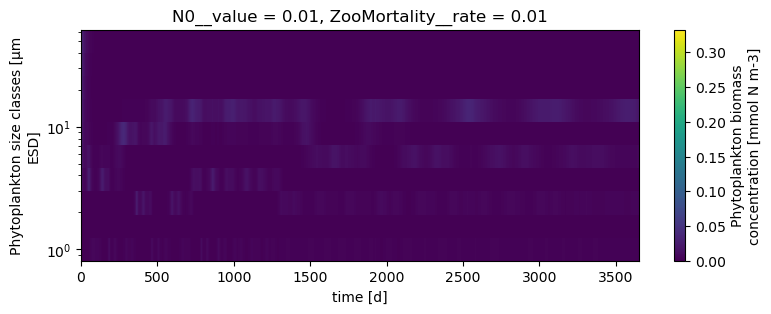

In [2]:
ivp_results.isel(N0__value=0, ZooMortality__rate=0).Phytoplankton__biomass.plot(yscale='log', aspect=3, size=3)

In [3]:

# --- 2. Calculate Mean of Last 1000 Steps ---
print("Calculating mean values for initial conditions...")
# Select variables and get the mean of the last 1000 time steps
mean_results = ivp_results[['Nutrient__value','Phytoplankton__biomass', 'Zooplankton__biomass']] \
                         .isel(time=slice(-1000, None)) \
                         .mean(dim='time')

print(mean_results)



Calculating mean values for initial conditions...
<xarray.Dataset> Size: 421kB
Dimensions:                 (ZooMortality__rate: 50, N0__value: 50, phyto: 10,
                             zoo: 10)
Coordinates:
  * ZooMortality__rate      (ZooMortality__rate) float64 400B 0.01 ... 5.0
  * N0__value               (N0__value) float64 400B 0.01 0.1118 ... 4.898 5.0
  * phyto                   (phyto) float64 80B 1.0 1.544 2.385 ... 32.37 50.0
  * zoo                     (zoo) float64 80B 2.16 4.703 ... 1.091e+03 2.375e+03
Data variables:
    Nutrient__value         (ZooMortality__rate, N0__value) float64 20kB 0.27...
    Phytoplankton__biomass  (ZooMortality__rate, N0__value, phyto) float64 200kB ...
    Zooplankton__biomass    (ZooMortality__rate, N0__value, zoo) float64 200kB ...


In [4]:

# --- 3. Define the Initial Value Mapping ---
# Maps: {Variable name in mean_results} -> {Parameter name in model_setup_stability}
iv_map = {
    'Nutrient__value': 'Nutrient__value_init',
    'Phytoplankton__biomass':'Phytoplankton__biomass_init',
    'Zooplankton__biomass':'Zooplankton__biomass_init'
}

# --- 4. Run the Stability Scan ---
print("Running stability scan with dynamic initial values...")
stability_results = run_xso_stabilityscan(
    model_file_name='ASTroCAT',
    model_name='model',
    model_setup_name='model_setup_stability', # <-- Your IVP setup
    param_name='N0__value',
    param_values=N0__value_scan,
    param_name2='ZooMortality__rate',
    param_values2=ZooMortality__rate_scan,
    processes=20,
    initial_values_ds=mean_results,      # <-- Pass the mean results
    iv_mapping=iv_map                    # <-- Pass the name mapping
)

# Display the final result
if stability_results is not None:
    print("\nFinal Stability Scan Output Dataset:")
    print(stability_results)
    print("\nStability data:")
    print(stability_results['stability'])

PROGRESS: Completed 50/50 outer points. (N0__value = 4.898163265306122).

2D Stability Scan complete. Total Time taken: 18.62642 seconds.

Final Stability Scan Output Dataset:
<xarray.Dataset> Size: 11MB
Dimensions:                          (ZooMortality__rate: 50, N0__value: 50,
                                      zoo: 10, time: 2, phyto: 10, clock: 2)
Coordinates:
  * ZooMortality__rate               (ZooMortality__rate) float64 400B 0.01 ....
  * N0__value                        (N0__value) float64 400B 0.01 ... 5.0
  * zoo                              (zoo) float64 80B 2.16 4.703 ... 2.375e+03
  * time                             (time) float64 16B 0.0 1.0
  * phyto                            (phyto) float64 80B 1.0 1.544 ... 50.0
  * clock                            (clock) int64 16B 0 1
Data variables: (12/45)
    Core__solver_type                (ZooMortality__rate, N0__value) <U9 90kB ...
    GGE__assimilated_consumer        (ZooMortality__rate, N0__value) <U1 10kB ...
    GG

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

# 1. Select Steady State
ds_ss = stability_results.isel(time=-1)

# 2. Vectorized Binning (Applies to all N0 and Mortality dims automatically)
# Phytoplankton Bins
pico = ds_ss.Phytoplankton__biomass.where(ds_ss.phyto <= 2, drop=True).sum(dim='phyto')
nano = ds_ss.Phytoplankton__biomass.where((ds_ss.phyto > 2) & (ds_ss.phyto <= 20), drop=True).sum(dim='phyto')
micro = ds_ss.Phytoplankton__biomass.where(ds_ss.phyto > 20, drop=True).sum(dim='phyto')

# Zooplankton Bins
z200 = ds_ss.Zooplankton__biomass.where(ds_ss.zoo <= 200, drop=True).sum(dim='zoo')
z500 = ds_ss.Zooplankton__biomass.where((ds_ss.zoo > 200) & (ds_ss.zoo <= 500), drop=True).sum(dim='zoo')
zlarge = ds_ss.Zooplankton__biomass.where(ds_ss.zoo > 500, drop=True).sum(dim='zoo')

# Combine into a new handy Dataset for plotting
ds_binned = xr.Dataset(
    {
        "Pico": pico, "Nano": nano, "Micro": micro,
        "Z200": z200, "Z500": z500, "ZLarge": zlarge,
        "Nutrient": ds_ss.Nutrient__value
    }
)

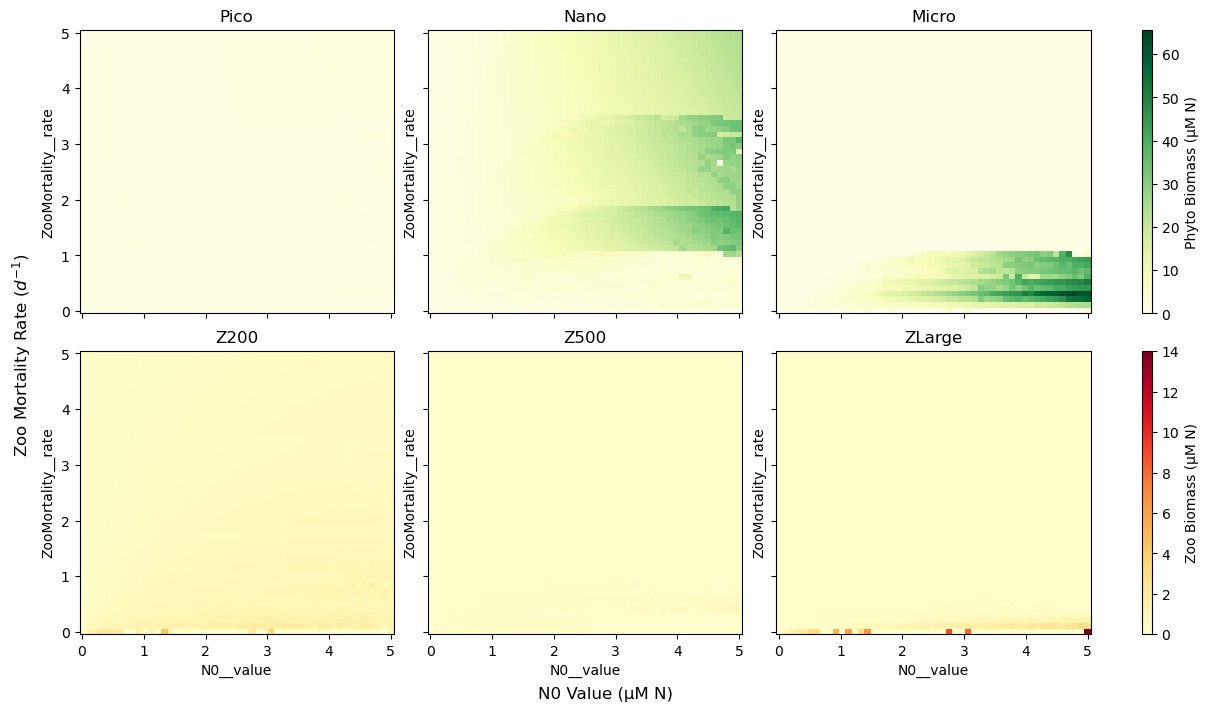

In [6]:
# 3. Determine Shared Color Limits
# We use .compute() or .values to get the actual numbers for comparison
max_phyto = max(ds_binned.Pico.max(), ds_binned.Nano.max(), ds_binned.Micro.max()).values
max_zoo = max(ds_binned.Z200.max(), ds_binned.Z500.max(), ds_binned.ZLarge.max()).values

# 4. Plotting
fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharex=True, sharey=True, constrained_layout=True)

# Define plotting parameters for each row
phyto_vars = ['Pico', 'Nano', 'Micro']
zoo_vars = ['Z200', 'Z500', 'ZLarge']

# --- Row 1: Phytoplankton (Green Colormap) ---
for i, var in enumerate(phyto_vars):
    ax = axes[0, i]
    # We save the mappable object 'im' to create the colorbar later
    im_phyto = ds_binned[var].plot.pcolormesh(
        ax=ax,
        x='N0__value',
        y='ZooMortality__rate',
        vmin=0, vmax=max_phyto,  # Shared limits
        cmap='YlGn',             # Phytoplankton colormap
        add_colorbar=False       # We will add a shared one later
    )
    ax.set_title(var)
    ax.set_xlabel('') # Remove inner x-labels

# --- Row 2: Zooplankton (Red-Orange Colormap) ---
for i, var in enumerate(zoo_vars):
    ax = axes[1, i]
    im_zoo = ds_binned[var].plot.pcolormesh(
        ax=ax,
        x='N0__value',
        y='ZooMortality__rate',
        vmin=0, vmax=max_zoo,    # Shared limits
        cmap='YlOrRd',           # Zooplankton colormap
        add_colorbar=False
    )
    ax.set_title(var)

# 5. Add Shared Colorbars
# Add colorbar for Phyto (Row 1)
cbar_phyto = fig.colorbar(im_phyto, ax=axes[0, :], orientation='vertical', aspect=30)
cbar_phyto.set_label('Phyto Biomass (µM N)')

# Add colorbar for Zoo (Row 2)
cbar_zoo = fig.colorbar(im_zoo, ax=axes[1, :], orientation='vertical', aspect=30)
cbar_zoo.set_label('Zoo Biomass (µM N)')

# Global labels
fig.supylabel(f"Zoo Mortality Rate ($d^{{-1}}$)")
fig.supxlabel("N0 Value (µM N)")

plt.show()

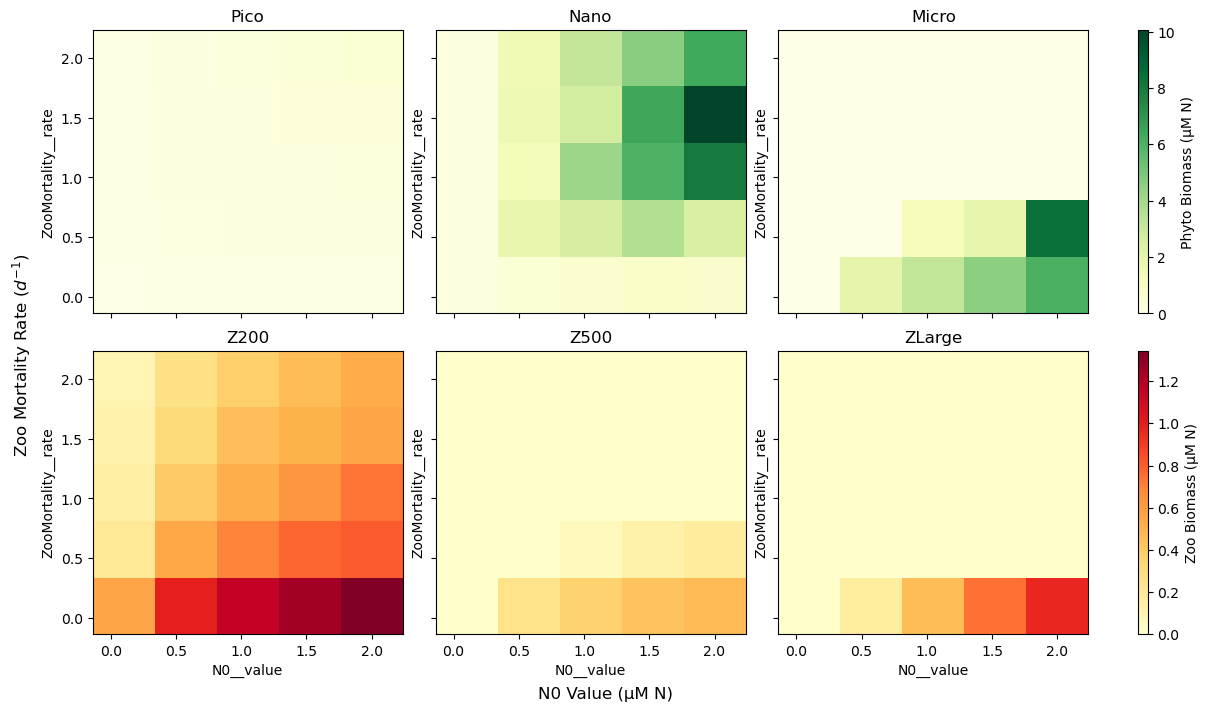

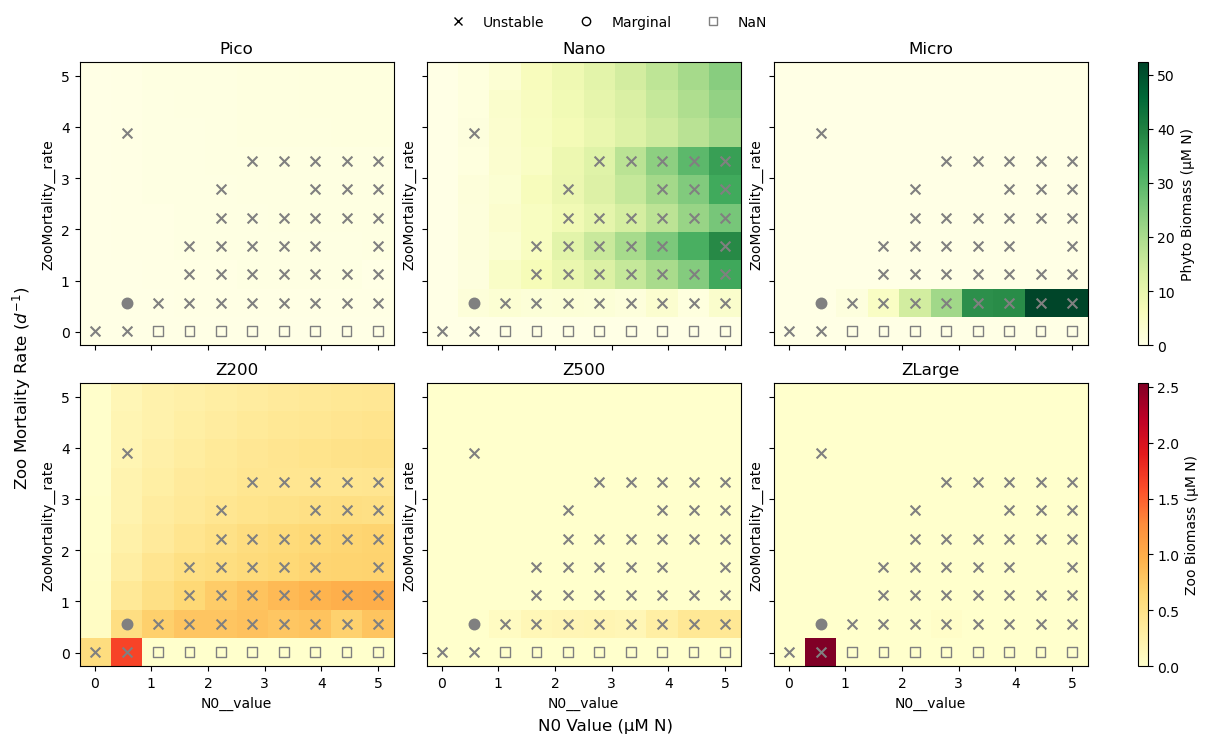

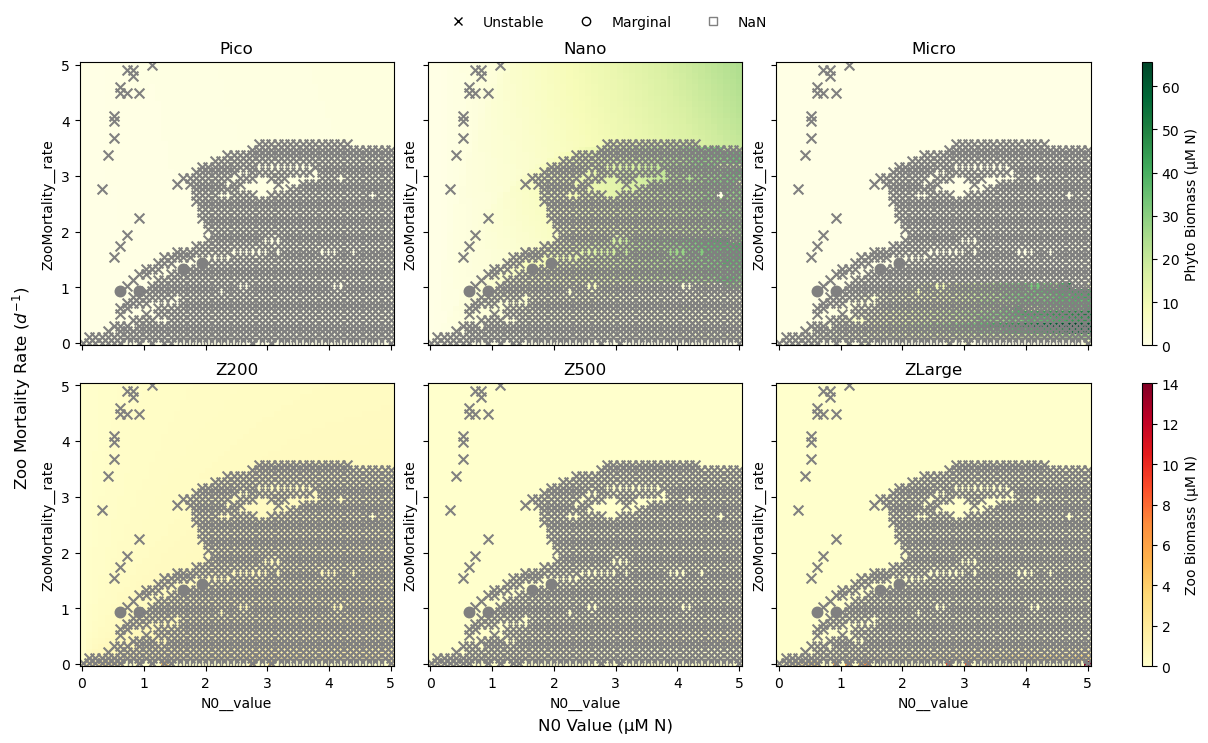

In [7]:

# 2. Extract Stability Data
# Assuming stability_results is the dataset containing the 'stability' DataArray
stab_da = stability_results['stability']

# Create masks for plotting
# We use .isin() for cleaner selection of multiple matching strings if needed
unstable_mask = stab_da == 'unstable'
marginal_mask = stab_da == 'marginal'

# Get coordinates for the scatter plot
# We treat the DataArray as a 2D grid
X, Y = np.meshgrid(stab_da.N0__value, stab_da.ZooMortality__rate)

# 3. Define Plotting Limits (Shared Colorbars)
max_phyto = max(ds_binned.Pico.max(), ds_binned.Nano.max(), ds_binned.Micro.max()).values
max_zoo = max(ds_binned.Z200.max(), ds_binned.Z500.max(), ds_binned.ZLarge.max()).values

# 4. Plotting
fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharex=True, sharey=True, constrained_layout=True)

phyto_vars = ['Pico', 'Nano', 'Micro']
zoo_vars = ['Z200', 'Z500', 'ZLarge']

# Helper function to overlay stability
def overlay_stability(ax):
    # Plot Unstable (White 'x' for high contrast on dark heatmap, or Black 'x')
    # Using dims to align correctly if 1D coords are different shapes
    ax.scatter(X[unstable_mask], Y[unstable_mask], 
               marker='x', s=50, color='grey', linewidth=1.5, label='Unstable')
    
    # Plot Marginal (White circles)
    ax.scatter(X[marginal_mask], Y[marginal_mask], 
               marker='o', s=50, facecolors='grey',  linewidth=1.5, label='Marginal')

    # Create the mask (xarray's isnull handles the mixed types correctly)
    nan_mask = stab_da.isnull()
    
    # Plot them (e.g., as gray squares or questions marks)
    ax.scatter(X[nan_mask], Y[nan_mask], marker='s', facecolors='none', edgecolors='gray', s=50, label='NaN')

# --- Row 1: Phytoplankton ---
for i, var in enumerate(phyto_vars):
    ax = axes[0, i]
    im_phyto = ds_binned[var].plot.pcolormesh(
        ax=ax, x='N0__value', y='ZooMortality__rate',
        vmin=0, vmax=max_phyto, cmap='YlGn', add_colorbar=False
    )
    overlay_stability(ax)
    ax.set_title(var)
    ax.set_xlabel('')

# --- Row 2: Zooplankton ---
for i, var in enumerate(zoo_vars):
    ax = axes[1, i]
    im_zoo = ds_binned[var].plot.pcolormesh(
        ax=ax, x='N0__value', y='ZooMortality__rate',
        vmin=0, vmax=max_zoo, cmap='YlOrRd', add_colorbar=False
    )
    overlay_stability(ax)
    ax.set_title(var)

# 5. Colorbars & Legend
cbar_phyto = fig.colorbar(im_phyto, ax=axes[0, :], orientation='vertical', aspect=30)
cbar_phyto.set_label('Phyto Biomass (µM N)')

cbar_zoo = fig.colorbar(im_zoo, ax=axes[1, :], orientation='vertical', aspect=30)
cbar_zoo.set_label('Zoo Biomass (µM N)')

# Create a custom legend for stability markers (only needs to be done once)
# We add it to the top right axes or outside
handles = [
    plt.Line2D([0], [0], marker='x', color='w', markeredgecolor='k', label='Unstable', linestyle=''),
    plt.Line2D([0], [0], marker='o', color='w', markeredgecolor='k', label='Marginal', linestyle=''),
    plt.Line2D([0], [0], marker='s', color='w', markeredgecolor='gray', label='NaN', linestyle='')
]
fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=3, frameon=False)

fig.supylabel(f"Zoo Mortality Rate ($d^{{-1}}$)")
fig.supxlabel("N0 Value (µM N)")

plt.show()

0.0022957046426156607 65.70510115735065
0.005088903950326024 14.038584943609902


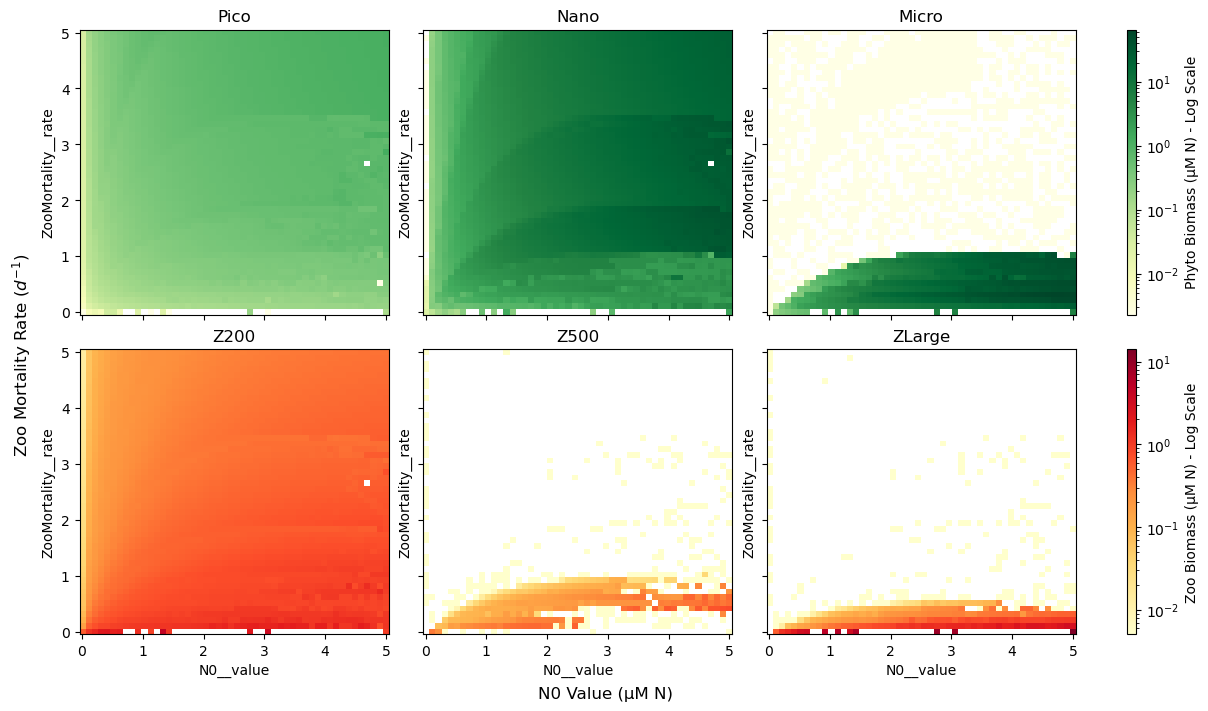

In [10]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors  # <--- NEW IMPORT
import numpy as np

# ... (Previous data setup code) ...

# 3. Determine Shared Color Limits (Log Scale)
# Helper to find min/max excluding zeros and NaNs
def get_log_limits(variables):
    # Stack values into one array to check global min/max
    data = np.stack([ds_binned[v].values for v in variables])
    # Max is standard
    vmax = np.nanmax(data)
    # Min must be the smallest value GREATER than 0
    vmin = np.nanmin(data[data > 0.001]) 
    print(vmin, vmax)
    return vmin, vmax

phyto_vars = ['Pico', 'Nano', 'Micro']
zoo_vars = ['Z200', 'Z500', 'ZLarge']

vmin_phyto, vmax_phyto = get_log_limits(phyto_vars)
vmin_zoo, vmax_zoo = get_log_limits(zoo_vars)

# 4. Plotting
fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharex=True, sharey=True, constrained_layout=True)

# --- Row 1: Phytoplankton ---
for i, var in enumerate(phyto_vars):
    ax = axes[0, i]
    im_phyto = ds_binned[var].plot.pcolormesh(
        ax=ax,
        x='N0__value',
        y='ZooMortality__rate',
        # CHANGED: Use norm instead of vmin/vmax directly
        norm=colors.LogNorm(vmin=vmin_phyto, vmax=vmax_phyto),
        cmap='YlGn',
        add_colorbar=False
    )
    # Overlay stability (assuming you have the function from previous step)
    # overlay_stability(ax) 
    ax.set_title(var)
    ax.set_xlabel('')

# --- Row 2: Zooplankton ---
for i, var in enumerate(zoo_vars):
    ax = axes[1, i]
    im_zoo = ds_binned[var].plot.pcolormesh(
        ax=ax,
        x='N0__value',
        y='ZooMortality__rate',
        # CHANGED: Use norm instead of vmin/vmax directly
        norm=colors.LogNorm(vmin=vmin_zoo, vmax=vmax_zoo),
        cmap='YlOrRd',
        add_colorbar=False
    )
    # overlay_stability(ax)
    ax.set_title(var)

# 5. Add Shared Colorbars
cbar_phyto = fig.colorbar(im_phyto, ax=axes[0, :], orientation='vertical', aspect=30)
cbar_phyto.set_label('Phyto Biomass (µM N) - Log Scale')

cbar_zoo = fig.colorbar(im_zoo, ax=axes[1, :], orientation='vertical', aspect=30)
cbar_zoo.set_label('Zoo Biomass (µM N) - Log Scale')

fig.supylabel(f"Zoo Mortality Rate ($d^{{-1}}$)")
fig.supxlabel("N0 Value (µM N)")

plt.show()

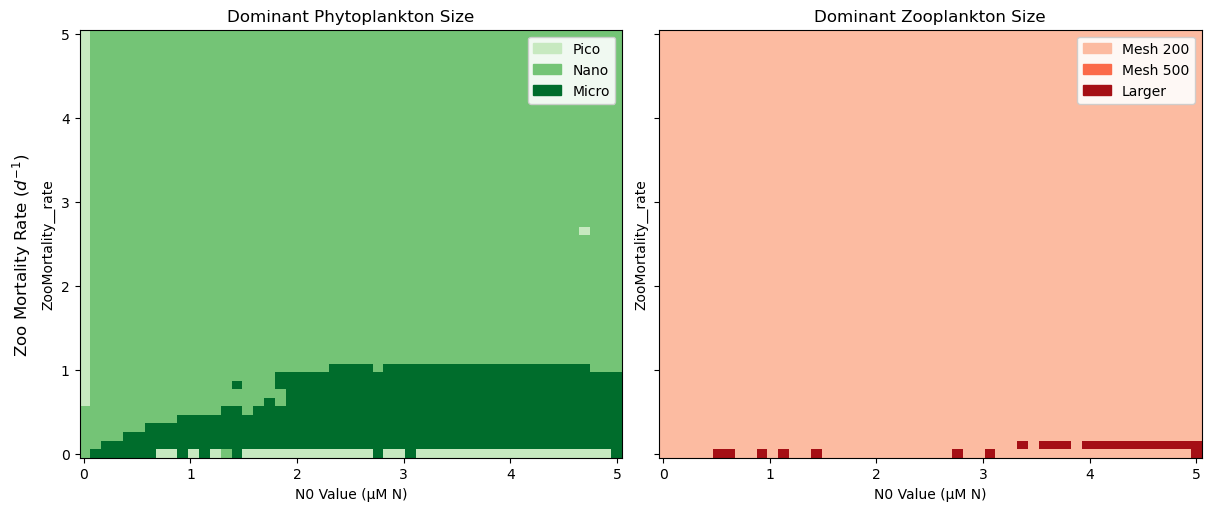

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import xarray as xr

# 1. Determine Dominance
# Stack the variables along a new dimension 'size_class' and find the index of the max value
# Order matters: 0=Pico, 1=Nano, 2=Micro
phyto_stack = xr.concat([ds_binned.Pico, ds_binned.Nano, ds_binned.Micro], dim='class')
phyto_dom = phyto_stack.argmax(dim='class') 

# Order matters: 0=Z200, 1=Z500, 2=ZLarge
zoo_stack = xr.concat([ds_binned.Z200, ds_binned.Z500, ds_binned.ZLarge], dim='class')
zoo_dom = zoo_stack.argmax(dim='class')

# 2. Define Discrete Colormaps & Legends
# Colors: Light -> Medium -> Dark to represent increasing size
colors_phyto = ['#c7e9c0', '#74c476', '#006d2c'] # Light Green, Med Green, Dark Green
cmap_phyto = ListedColormap(colors_phyto)
labels_phyto = ['Pico', 'Nano', 'Micro']

colors_zoo = ['#fcbba1', '#fb6a4a', '#a50f15']   # Light Red, Med Red, Dark Red
cmap_zoo = ListedColormap(colors_zoo)
labels_zoo = ['Mesh 200', 'Mesh 500', 'Larger']

# 3. Plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True, constrained_layout=True)

# --- Phyto Dominance ---
phyto_dom.plot.pcolormesh(
    ax=axes[0], x='N0__value', y='ZooMortality__rate',
    cmap=cmap_phyto, add_colorbar=False, vmin=0, vmax=2
)
axes[0].set_title('Dominant Phytoplankton Size')
axes[0].set_xlabel("N0 Value (µM N)")

# Create Custom Legend for Phyto
patches_phyto = [mpatches.Patch(color=c, label=l) for c, l in zip(colors_phyto, labels_phyto)]
axes[0].legend(handles=patches_phyto, loc='upper right', framealpha=0.9)
# Optional: Overlay stability
# overlay_stability(axes[0]) 

# --- Zoo Dominance ---
zoo_dom.plot.pcolormesh(
    ax=axes[1], x='N0__value', y='ZooMortality__rate',
    cmap=cmap_zoo, add_colorbar=False, vmin=0, vmax=2
)
axes[1].set_title('Dominant Zooplankton Size')
axes[1].set_xlabel("N0 Value (µM N)")

# Create Custom Legend for Zoo
patches_zoo = [mpatches.Patch(color=c, label=l) for c, l in zip(colors_zoo, labels_zoo)]
axes[1].legend(handles=patches_zoo, loc='upper right', framealpha=0.9)
# Optional: Overlay stability
# overlay_stability(axes[1]) 

fig.supylabel(f"Zoo Mortality Rate ($d^{{-1}}$)")

plt.show()

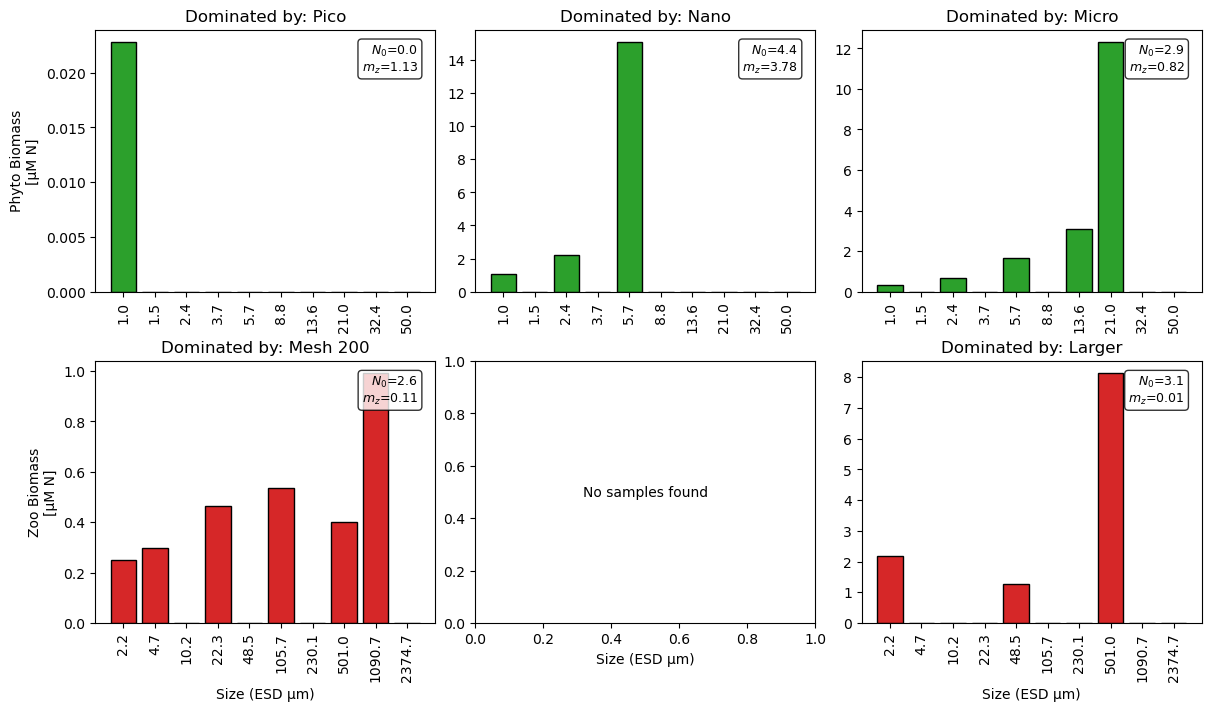

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Setup labels and colors
p_labels = ['Pico', 'Nano', 'Micro']
z_labels = ['Mesh 200', 'Mesh 500', 'Larger']
class_indices = [0, 1, 2]

fig, axes = plt.subplots(2, 3, figsize=(12, 7), constrained_layout=True)

# Helper function to get random coordinates for a specific dominance class
def get_random_sample(dom_array, class_idx):
    # Find all indices (mortality_idx, n0_idx) where this class dominates
    matches = np.argwhere(dom_array.values == class_idx)
    
    if len(matches) == 0:
        return None
    
    # Pick one random index pair
    rand_idx = matches[np.random.choice(len(matches))]
    
    # Return the data subset for that specific grid cell
    # rand_idx[0] is ZooMortality, rand_idx[1] is N0
    return ds_ss.isel(ZooMortality__rate=rand_idx[0], N0__value=rand_idx[1])

# --- Row 1: Phytoplankton Dominance Examples ---
for i, label in enumerate(p_labels):
    ax = axes[0, i]
    sample = get_random_sample(phyto_dom, i)
    
    if sample:
        # Plot the full 10-class spectrum
        x_vals = np.arange(len(sample.phyto))
        ax.bar(x_vals, sample.Phytoplankton__biomass, color='tab:green', edgecolor='k')
        
        # Formatting
        ax.set_title(f"Dominated by: {label}")
        ax.set_xticks(x_vals)
        ax.set_xticklabels([f"{x:.1f}" for x in sample.phyto.values], rotation=90)
        
        # Add parameter context
        n0 = sample.N0__value.item()
        mort = sample.ZooMortality__rate.item()
        ax.text(0.95, 0.95, f"$N_0$={n0:.1f}\n$m_z$={mort:.2f}", 
                transform=ax.transAxes, ha='right', va='top', fontsize=9, 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    else:
        ax.text(0.5, 0.5, "No samples found", ha='center', va='center')
    
    if i == 0: ax.set_ylabel("Phyto Biomass\n[µM N]")

# --- Row 2: Zooplankton Dominance Examples ---
for i, label in enumerate(z_labels):
    ax = axes[1, i]
    sample = get_random_sample(zoo_dom, i)
    
    if sample:
        x_vals = np.arange(len(sample.zoo))
        ax.bar(x_vals, sample.Zooplankton__biomass, color='tab:red', edgecolor='k')
        
        ax.set_title(f"Dominated by: {label}")
        ax.set_xticks(x_vals)
        ax.set_xticklabels([f"{x:.1f}" for x in sample.zoo.values], rotation=90)
        
        # Add parameter context
        n0 = sample.N0__value.item()
        mort = sample.ZooMortality__rate.item()
        ax.text(0.95, 0.95, f"$N_0$={n0:.1f}\n$m_z$={mort:.2f}", 
                transform=ax.transAxes, ha='right', va='top', fontsize=9, 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    else:
        ax.text(0.5, 0.5, "No samples found", ha='center', va='center')

    if i == 0: ax.set_ylabel("Zoo Biomass\n[µM N]")
    ax.set_xlabel("Size (ESD µm)")

plt.show()